# CUSTOMER SEGMENTATION DATA ANALYSIS

In [1]:
# import the files

In [2]:
import numpy as np
import pandas as pd

In [3]:
data=pd.read_csv("customer.csv")

In [4]:
data

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93
4,5,65,Female,140621,21,3,25,Electronics,347.08
...,...,...,...,...,...,...,...,...,...
995,996,57,Male,112170,57,6,1,Clothing,313.64
996,997,23,Other,65337,76,10,23,Groceries,632.83
997,998,23,Male,113097,40,5,42,Sports,75.09
998,999,22,Female,113695,63,7,44,Electronics,505.16


In [5]:
#check my data

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1000 non-null   int64  
 1   age                   1000 non-null   int64  
 2   gender                1000 non-null   object 
 3   income                1000 non-null   int64  
 4   spending_score        1000 non-null   int64  
 5   membership_years      1000 non-null   int64  
 6   purchase_frequency    1000 non-null   int64  
 7   preferred_category    1000 non-null   object 
 8   last_purchase_amount  1000 non-null   float64
dtypes: float64(1), int64(6), object(2)
memory usage: 70.4+ KB


In [7]:
data.describe()

,id,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,43.783000,88500.800000,50.685000,5.46900,26.596000,492.348670
std,288.819436,15.042213,34230.771122,28.955175,2.85573,14.243654,295.744253
min,1.000000,18.000000,30004.000000,1.000000,1.00000,1.000000,10.400000
25%,250.750000,30.000000,57911.750000,26.000000,3.00000,15.000000,218.762500
50%,500.500000,45.000000,87845.500000,50.000000,5.00000,27.000000,491.595000
75%,750.250000,57.000000,116110.250000,76.000000,8.00000,39.000000,747.170000
max,1000.000000,69.000000,149973.000000,100.000000,10.00000,50.000000,999.740000


In [8]:
data.shape

(1000, 9)

In [9]:
data.head()

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93
4,5,65,Female,140621,21,3,25,Electronics,347.08


In [10]:
data.tail()

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
995,996,57,Male,112170,57,6,1,Clothing,313.64
996,997,23,Other,65337,76,10,23,Groceries,632.83
997,998,23,Male,113097,40,5,42,Sports,75.09
998,999,22,Female,113695,63,7,44,Electronics,505.16
999,1000,36,Female,90420,7,2,31,Groceries,669.26


In [11]:
#null values

In [12]:
data.isnull().sum()

id                      0
age                     0
gender                  0
income                  0
spending_score          0
membership_years        0
purchase_frequency      0
preferred_category      0
last_purchase_amount    0
dtype: int64

In [13]:
#duplciates

In [14]:
data.duplicated().sum()

np.int64(0)

In [15]:
# otuliers

In [17]:
Q1= data[['income','last_purchase_amount']].quantile(0.25)
Q3= data[['income','last_purchase_amount']].quantile(0.75)
IQR=Q3-Q1
print("Q1: ", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1:  income                  57911.7500
last_purchase_amount      218.7625
Name: 0.25, dtype: float64
Q3: income                  116110.25
last_purchase_amount       747.17
Name: 0.75, dtype: float64
IQR: income                  58198.5000
last_purchase_amount      528.4075
dtype: float64


In [18]:
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Lower BOUND: ", lower_bound)
print("upper bound :", upper_bound)

Lower BOUND:  income                 -29386.00000
last_purchase_amount     -573.84875
dtype: float64
upper bound : income                  203408.00000
last_purchase_amount      1539.78125
dtype: float64


In [19]:
outliers=data[
    (data[['income','last_purchase_amount']]<lower_bound)|
    (data[['income','last_purchase_amount']]>upper_bound)
    ]
print(outliers)

     id  age gender  income  spending_score  membership_years  \
0   NaN  NaN    NaN     NaN             NaN               NaN   
1   NaN  NaN    NaN     NaN             NaN               NaN   
2   NaN  NaN    NaN     NaN             NaN               NaN   
3   NaN  NaN    NaN     NaN             NaN               NaN   
4   NaN  NaN    NaN     NaN             NaN               NaN   
..   ..  ...    ...     ...             ...               ...   
995 NaN  NaN    NaN     NaN             NaN               NaN   
996 NaN  NaN    NaN     NaN             NaN               NaN   
997 NaN  NaN    NaN     NaN             NaN               NaN   
998 NaN  NaN    NaN     NaN             NaN               NaN   
999 NaN  NaN    NaN     NaN             NaN               NaN   

     purchase_frequency preferred_category  last_purchase_amount  
0                   NaN                NaN                   NaN  
1                   NaN                NaN                   NaN  
2                 

In [20]:
# copy 

In [21]:
data_Clean=data.copy()

In [22]:
data_Clean

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93
4,5,65,Female,140621,21,3,25,Electronics,347.08
...,...,...,...,...,...,...,...,...,...
995,996,57,Male,112170,57,6,1,Clothing,313.64
996,997,23,Other,65337,76,10,23,Groceries,632.83
997,998,23,Male,113097,40,5,42,Sports,75.09
998,999,22,Female,113695,63,7,44,Electronics,505.16


In [23]:
# fearture engineering 

In [24]:
# to add a column based on the exisitng columns 

In [25]:
# lifetime value analysis on the basis of membership years

In [26]:
# lieftime value analysis - it means the potenaial customers for the business who are highly profitable 

In [31]:
data['lifetime_value']=(data['last_purchase_amount']*data['membership_years'] * data['purchase_frequency'])
data[['last_purchase_amount','membership_years','purchase_frequency','lifetime_value']].head()


,last_purchase_amount,membership_years,purchase_frequency,lifetime_value
0,113.53,3,24,8174.16
1,41.93,2,42,3522.12
2,424.36,2,28,23764.16
3,991.93,9,5,44636.85
4,347.08,3,25,26031.00


In [32]:
#pd.qcut()- ranks data ranking 

In [44]:
data['customer_category']=pd.qcut(
    data['lifetime_value'],
    q=3,
    labels=['Low value','medium value','high value']
)
data[['lifetime_value','customer_category']]

,lifetime_value,customer_category
0,8174.16,Low value
1,3522.12,Low value
2,23764.16,medium value
3,44636.85,medium value
4,26031.00,medium value
...,...,...
995,1881.84,Low value
996,145550.90,high value
997,15768.90,Low value
998,155589.28,high value


In [39]:
data

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount,lieftime_value,lifeftime_value,lifetime_value,customer_category
0,1,38,Female,99342,90,3,24,Groceries,113.53,72,72,8174.16,Low value
1,2,21,Female,78852,60,2,42,Sports,41.93,84,84,3522.12,Low value
2,3,60,Female,126573,30,2,28,Clothing,424.36,56,56,23764.16,medium value
3,4,40,Other,47099,74,9,5,Home & Garden,991.93,45,45,44636.85,medium value
4,5,65,Female,140621,21,3,25,Electronics,347.08,75,75,26031.00,medium value
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,57,Male,112170,57,6,1,Clothing,313.64,6,6,1881.84,Low value
996,997,23,Other,65337,76,10,23,Groceries,632.83,230,230,145550.90,high value
997,998,23,Male,113097,40,5,42,Sports,75.09,210,210,15768.90,Low value
998,999,22,Female,113695,63,7,44,Electronics,505.16,308,308,155589.28,high value


# DATA ANALYSIS OR EDA (EXPLORATORY DATA ANALYSIS)

In [41]:
data.groupby('customer_category')['lifetime_value'].sum()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1452\755428873.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('customer_category')['lifetime_value'].sum()


customer_category
Low value        2941166.04
medium value    14711255.55
high value      55895541.57
Name: lifetime_value, dtype: float64

In [43]:
data.groupby('customer_category')['lifetime_value'].agg(['min','max','mean','count'])

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1452\1257314192.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('customer_category')['lifetime_value'].agg(['min','max','mean','count'])


,min,max,mean,count
customer_category,,,,
Low value,59.16,21597.76,8832.330450,333
medium value,21712.88,75255.60,44177.944595,333
high value,75320.40,436973.67,167351.920868,334


In [46]:
#checking column names

In [47]:
data.columns

Index(['id', 'age', 'gender', 'income', 'spending_score', 'membership_years',
       'purchase_frequency', 'preferred_category', 'last_purchase_amount',
       'lieftime_value', 'lifeftime_value', 'lifetime_value',
       'customer_category'],
      dtype='object')

# number of customers in each gender and age group

In [48]:
print(data['gender'].value_counts())

gender
Male      357
Other     327
Female    316
Name: count, dtype: int64


In [49]:
print(data['age'].value_counts())

age
47    32
30    30
33    29
45    29
53    28
19    28
69    28
64    27
41    25
61    24
43    23
60    23
23    23
48    22
51    22
22    22
18    21
57    21
26    21
56    20
27    20
63    20
29    20
62    20
68    19
28    19
54    18
46    18
59    18
32    18
49    18
31    18
40    18
36    17
39    16
58    16
38    16
50    16
55    16
52    15
66    15
21    14
65    14
25    13
35    12
37    12
20    12
42    11
24    11
44    11
34    11
67    10
Name: count, dtype: int64


In [50]:
# value counts is used to the frequency 

# analyse spending and income

In [51]:
data.groupby('age')['purchase_frequency'].sum()

age
18    513
19    844
20    298
21    358
22    671
23    616
24    277
25    457
26    572
27    510
28    485
29    546
30    759
31    411
32    474
33    851
34    297
35    297
36    392
37    393
38    318
39    494
40    364
41    705
42    337
43    666
44    319
45    824
46    512
47    770
48    593
49    426
50    393
51    603
52    401
53    859
54    510
55    381
56    529
57    557
58    396
59    503
60    615
61    512
62    544
63    549
64    633
65    421
66    351
67    230
68    651
69    609
Name: purchase_frequency, dtype: int64

In [55]:
corr=(data[['income','spending_score']].corr())

In [56]:
corr

,income,spending_score
income,1.00000,0.00002
spending_score,0.00002,1.00000


In [57]:
# channge in income is not changing the spending score

In [58]:
#analyse lieftime value with customer catgory

In [61]:
av_lifetime_value=data.groupby('customer_category',)['lifetime_value'].mean()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1452\2234314074.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  av_lifetime_value=data.groupby('customer_category',)['lifetime_value'].mean()


In [62]:
av_lifetime_value

customer_category
Low value         8832.330450
medium value     44177.944595
high value      167351.920868
Name: lifetime_value, dtype: float64

# analyse purchase behaviour based on product category 

In [80]:
ANALYSIS=data.groupby('preferred_category')['last_purchase_amount'].agg(['mean','median','count']).sort_values('mean',ascending=False)

In [81]:
ANALYSIS

,mean,median,count
preferred_category,,,
Home & Garden,505.600631,506.785,206
Electronics,496.632279,506.700,215
Clothing,489.648412,486.230,170
Groceries,487.279397,488.070,199
Sports,481.953190,484.465,210


In [66]:
#prefered category based on income and age

In [75]:
data.groupby(['preferred_category','customer_category'])['income'].sum()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1452\4165106897.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(['preferred_category','customer_category'])['income'].sum()


preferred_category  customer_category
Clothing            Low value            5537565
                    medium value         5219113
                    high value           4432824
Electronics         Low value            5967993
                    medium value         6697222
                    high value           6493723
Groceries           Low value            6439016
                    medium value         4967335
                    high value           6044232
Home & Garden       Low value            6109353
                    medium value         6154602
                    high value           6049551
Sports              Low value            6333893
                    medium value         5805942
                    high value           6248436
Name: income, dtype: int64

# data visualization

In [76]:
import matplotlib.pyplot as plt

In [77]:
print(dir(plt))

['AbstractContextManager', 'Annotation', 'Arrow', 'Artist', 'AutoLocator', 'AxLine', 'Axes', 'BackendFilter', 'Button', 'Circle', 'Colorizer', 'ColorizingArtist', 'Colormap', 'Enum', 'ExitStack', 'Figure', 'FigureBase', 'FigureCanvasBase', 'FigureManagerBase', 'FixedFormatter', 'FixedLocator', 'FormatStrFormatter', 'Formatter', 'FuncFormatter', 'GridSpec', 'IndexLocator', 'Line2D', 'LinearLocator', 'Locator', 'LogFormatter', 'LogFormatterExponent', 'LogFormatterMathtext', 'LogLocator', 'MaxNLocator', 'MouseButton', 'MultipleLocator', 'Normalize', 'NullFormatter', 'NullLocator', 'PolarAxes', 'Polygon', 'Rectangle', 'ScalarFormatter', 'Slider', 'Subplot', 'SubplotSpec', 'TYPE_CHECKING', 'Text', 'TickHelper', 'Widget', '_ColorizerInterface', '_NO_PYPLOT_NOTE', '_REPL_DISPLAYHOOK', '_ReplDisplayHook', '__annotations__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_add_pyplot_note', '_api', '_auto_draw_if_interactive', '_backend

In [ ]:
# help(plt)

# first of all whenver we do data visulaization in python we do the EDA (EXPLORATORY DATA ANALYSIS)

# WHICH CHART TO USE WHEN 

In [78]:
# BAR CHART - CATEGORIES
# PIE CHART - DISTRIBUTION (WHEN YOU HAVE VERY FEW CATEGORY)
# HISTOGRAM - TO SHOW THE BINS OR MID POINT 
# SCATTER PLOT - TO SHOW THE RELATION 


In [79]:
# SCATTER PLOT FOR CORRELATION

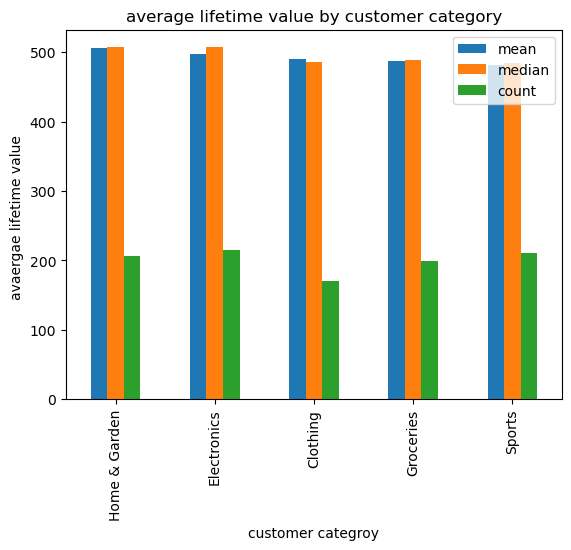

In [84]:
ANALYSIS.plot(kind='bar')
plt.title('average lifetime value by customer category')
plt.xlabel('customer categroy')
plt.ylabel('avaergae lifetime value ')
plt.show()